In [43]:
from Config import *
from Dataset import *
from Experiments import *
from Metric import *
from Model import *
from Utils import *
from FID import *
from Train import *

import gc

from diffusers import ConsistencyModelPipeline
import torch
from PIL import Image
import torchvision.transforms as T

class set_args:
    def __init__(self):
        self.seed = 5
        self.state = 'train'
        self.epochs = 150 # training epochs
        self.batch_size = 80
        self.dataset = 'Imagenet'#'MNIST'#'CIFAR10' 
        self.split_class= [0]

        #Load different model if TRUE
        self.load_different_model = False
        self.load_trained_model = False
        self.load_training_checkpoint = 30 #30,#200
        self.load_rd_training_checkpoint = 150

        self.sample_dir = 'Result'
        self.checkpoint_dir = 'Result'
        self.M = [0]
        self.I = [0]

        #Reduce training sample
        self.rd = 0.05
        self.training_anchor_num = 500 # training_anchor_num=200
        self.testing_anchor_num = 500 # testing_anchor_num=2500
        self.metric = 'L2'
        

        self.save_weight_dir = 'Result/CheckpointsMNIST/'

        
    
directory_init()

args = set_args()
seed_everything(args.seed) 


"""Merge both these"""
model_config = set_config(args, custom_dataset=args.dataset) 

model, sampler, trainer = model_init(args, model_config)

# FID

block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
InceptionV3_model = InceptionV3([block_idx])
InceptionV3_model=InceptionV3_model.cuda()



Config : Imagenet
Config : haha
loading model : c0_ckpt_30_.pt ......


c:\Users\user\Desktop\DDPM_XAI\Utils.py:799: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(


model load weight done.
update Sampler ...... done
update Trainer ...... done


c:\Users\user\.conda\envs\FID\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\.conda\envs\FID\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [44]:
import torch
from diffusers import ConsistencyModelPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

# 加載 Consistency Model
model_id = "openai/diffusers-cd_imagenet64_lpips"
pipe = ConsistencyModelPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe.to(device)




Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  5.73it/s]


ConsistencyModelPipeline {
  "_class_name": "ConsistencyModelPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "openai/diffusers-cd_imagenet64_lpips",
  "scheduler": [
    "diffusers",
    "CMStochasticIterativeScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

In [45]:
from collections import defaultdict

num_samples = 80
compare_samples = 5
#batch_size = 80

num_inference_steps = 10

latents = None
callback = None
callback_steps = 1
timesteps = None
generator = None
output_type = "pil"

XLA_AVAILABLE = False

img_size = pipe.unet.config.sample_size
device = pipe._execution_device

class_label = torch.tensor([1], device=device)

model_output_dict = {}

# 0. Prepare call parameters
img_size = pipe.unet.config.sample_size
device = pipe._execution_device

# 1. Check inputs
pipe.check_inputs(num_inference_steps, timesteps, latents, num_samples, img_size, callback_steps)

# 2. Prepare image latents
# Sample image latents x_0 ~ N(0, sigma_0^2 * I)
sample = pipe.prepare_latents(
    batch_size=num_samples,
    num_channels=pipe.unet.config.in_channels,
    height=img_size,
    width=img_size,
    dtype=pipe.unet.dtype,
    device=device,
    generator=None,
    latents=latents,
)

# 3. Handle class_labels for class-conditional models
class_labels = pipe.prepare_class_labels(num_samples, device, class_labels=class_label)

# 4. Prepare timesteps
if timesteps is not None:
    pipe.scheduler.set_timesteps(timesteps=timesteps, device=device)
    timesteps = pipe.scheduler.timesteps
    num_inference_steps = len(timesteps)
else:
    pipe.scheduler.set_timesteps(num_inference_steps)
    timesteps = pipe.scheduler.timesteps




In [46]:
pipe.scheduler.timesteps

tensor([ 1095.5067,   949.6027,   790.4186,   615.2925,   420.6723,   201.6680,
          -48.7176,  -341.0065,  -692.0998, -1131.7736], dtype=torch.float64)

In [24]:
def CM_edit_friendly_inversion(x_0, timestep, alpha_cumprod,  model, sampler):
    edit_friendly_noise_maps = []
    #for step in timesteps:
    # Generate noisy image xt via forward diffusion
    x_t_minus_one = forward_diffusion(x_0, alpha_cumprod, [timestep-1])[-1]
    x_t = forward_diffusion(x_0, alpha_cumprod, [timestep])[-1]
    #x_t = xt_info_sampledImgs[timestep]
    
    # Compute noise map z_t
    z_t = compute_noise_map(x_0, x_t_minus_one, x_t, alpha_cumprod, timestep, model, sampler)
    
    # Optional: Regularize z_t (e.g., add perceptual or latent loss)
    z_t = regularize_noise_map(z_t)

    
    edit_friendly_noise_maps.append(z_t)

    return edit_friendly_noise_maps[0]

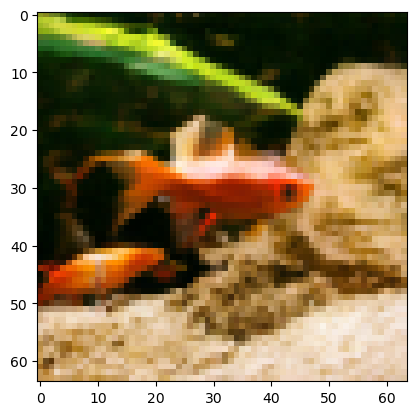

In [49]:
plt.imshow(sampledImgs[2].cpu().permute(1,2,0).numpy())

In [ ]:
args = args
device = model_config['device']
model_config = model_config

"""Initialize the config for the procedure"""
test_t = pipe.scheduler.timesteps

"""Merge with _procedure function"""
# None stands for unlimit
test_lim_i = 80 
train_lim_i = 80

training_anchor_num=500
testing_anchor_num=500


sample = pipe.prepare_latents(
            batch_size=num_samples,
            num_channels=pipe.unet.config.in_channels,
            height=img_size,
            width=img_size,
            dtype=pipe.unet.dtype,
            device=device,
            generator=None,
            latents=latents,
        )
        
data_idx = []
label_lst = []
ef_inversion_lst = []
h_lst = []
t_lst = []
kld_lst = []
is_train = []


mu_q_lst = []
sigma_q_lst = []
mu_p_lst = []
sigma_p_lst = []

betas = trainer.betas
alpha_t = 1.0 - betas
alpha_cumprod = torch.cumprod(alpha_t, dim=0)

#Function for adjusting weight to applying time step
test_t_ext_w = 0
test_t_int_w = 1
    
# Convert to tensor in range [-1, 1]
preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])
    
with torch.no_grad(): 
    """
    for _ in range(num_samples):
        image = pipe(num_inference_steps=None, timesteps=[10, 0], class_labels=1).images[0]
        image_tensor = preprocess(image).unsqueeze(0).to(model_config['device'])

        gen_images.append(image_tensor[0])
    """
    
    gen_images = []
    # 5. Denoising loop
    # Multistep sampling: implements Algorithm 1 in the paper
    with pipe.progress_bar(total=num_inference_steps) as progress_bar:
        for i, t in enumerate(test_t):
            scaled_sample = pipe.scheduler.scale_model_input(sample, t)
            model_output = pipe.unet(scaled_sample, t, class_labels=class_labels, return_dict=False)[0]
            model_output_dict[i] = model_output
            
            sample = pipe.scheduler.step(model_output, t, sample, generator=generator)[0]
    
            # call the callback, if provided
            progress_bar.update()

        # 6. Post-process image sample
        image = pipe.postprocess_image(sample, output_type=output_type)
        
        for n_s in range(num_samples):
            image_tensor = preprocess(image[n_s]).unsqueeze(0).to(model_config['device'])
            gen_images.append(image_tensor[0])
    
    sampledImgs = torch.stack(gen_images, dim=0)

    # Offload all models
    pipe.maybe_free_model_hooks()
        
    
    

x_tilde_0 = sampledImgs

dt_train = CUSTOM_DATASET(args, split=True)
train_dataset, _ = dt_train.load_dataset(custom_trasform=False)


dt = CUSTOM_DATASET(args, split=False)
_, test_dataset = dt.load_dataset(custom_trasform=False)


with torch.no_grad():
    features = {}

    def hook(module, input, output):
        features["mid_block"] = output
        
    hook_handle = pipe.unet.mid_block.register_forward_hook(hook)
    for test_t in test_t:
        test_t_ext = test_t * test_t_ext_w
        test_t_int = test_t * test_t_int_w

        """
        x_tilde_noise_map = []
        x_tilde_h_map = []
        #for n_batch in range(x_tilde_0.shape[0]):
            #ef_inversion_val_tilde = edit_friendly_inversion(x_tilde_0[n_batch], test_t, alpha_cumprod)
            #x_tilde_noise_map.append(ef_inversion_val_tilde)
        #x_tilde_noise_map = torch.stack(x_tilde_noise_map)

        for i, (train_img, train_label) in enumerate(train_dataset):
            # noise 
            x_0_train = train_dataset[i][0].to(device)
            ef_inversion_val = edit_friendly_inversion(x_0_train, test_t, alpha_cumprod)
            
            # h space
            base_n_t_h = x_0_train.new_ones([1, ], dtype=torch.long) * test_t
            h_train = model(x_0_train.unsqueeze(dim=0), base_n_t_h)
            
            # append 
            x_tilde_noise_map.append(ef_inversion_val)
            x_tilde_h_map.append(h_train)
            if i == 79:
                break
        """
        x_tilde_noise_map = []
        x_tilde_h_map = []
        
    
        for i in range(len(x_tilde_0)):
            if i == 80:
                break
            x_0_train = x_tilde_0[i].to(device)
            #ef_inversion_val = edit_friendly_inversion(x_0_train, test_t_ext, alpha_cumprod, model, sampler)
        
            # h space
            
            image_scaled = x_0_train.unsqueeze(0).half()
            pred_noise = pipe.unet(
                image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            """
            
            noisy_image = pipe.scheduler.add_noise(gen_dt.unsqueeze(0), torch.randn_like(gen_dt), t.unsqueeze(0)).half()
            noisy_image_scaled = min_max_scaler(noisy_image)

            pred_noise = pipe.unet(
                noisy_image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            """

            #hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

            # 正常呼叫 UNet
            output = pipe.unet(pred_noise, t, class_label)

            mid_block_output = features["mid_block"]

            #hook_handle.remove
            
            #base_n_t_h = x_0_train.new_ones([1, ], dtype=torch.long) * test_t_int
            #h_train = model(x_0_train.unsqueeze(dim=0), base_n_t_h)
            h_train = mid_block_output
            
            
        
            
            # append 
            #x_tilde_noise_map.append(ef_inversion_val)
            x_tilde_noise_map.append(x_0_train)
            x_tilde_h_map.append(h_train)
            
        
        
        x_tilde_noise_map = torch.stack(x_tilde_noise_map)
        x_tilde_h_map = torch.stack(x_tilde_h_map)
        
        for i, (img, label) in enumerate(test_dataset):
            if i == testing_anchor_num + 1:
                break
            x_0 = test_dataset[i][0].to(device).unsqueeze(0).half()
            pred_noise = pipe.unet(
                x_0, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            #x_tilde_t = trainer.get_step_xt(x_tilde_0, test_t)
            #timesteps = list(range(1000))
            
            #ef_inversion_val = edit_friendly_inversion(x_0, test_t_ext, alpha_cumprod, model, sampler)
            ef_inversion_val = x_0.squeeze(dim=0)

            #h_test = model(x_0.unsqueeze(dim=0), base_n_t_h)
            features = {}

            #hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

            # 正常呼叫 UNet
            output = pipe.unet(pred_noise, t, class_label)

            mid_block_output = features["mid_block"]

            #hook_handle.remove
            
            h_test = mid_block_output
            
            #print(kl_div_pixelwise.mean().cpu().numpy(), test_dataset[i][1])
            label_lst.append(str(label))
            #kld_lst.append(float(kl_div_pixelwise.mean().cpu().numpy()))
            #h_lst.append(h_diff)
            t_lst.append(test_t.item())

            mse_loss = nn.MSELoss()
            kld_loss = nn.KLDivLoss(reduction='batchmean')

            mse_diff = 0
            h_diff = 0
            kld_diff = 0

            input_t = F.log_softmax(ef_inversion_val.unsqueeze(dim=0), dim=1)
            target_t = F.softmax(x_tilde_noise_map, dim=1)
            kld_diff = kld_loss(input_t, target_t)



            for j in range(x_tilde_noise_map.shape[0]):
                mse_diff += compute_edit_distance(ef_inversion_val * 100, x_tilde_noise_map[j] * 100, 'mse') / (x_tilde_noise_map.shape[0])
                h_diff += compute_edit_distance(h_test, x_tilde_h_map[j], 'mse') / (x_tilde_noise_map.shape[0])
            
            ef_inversion_lst.append(round(float((mse_diff.cpu().numpy())), 4))
            h_lst.append(round(float(h_diff.cpu().numpy()), 4))
            kld_lst.append(round(float(kld_diff.cpu().numpy()), 4))
            data_idx.append(int(i))
            is_train.append(False)
            
            
            ##mu_q_lst.append(round(float((mu_q.cpu().numpy())), 4))
            #sigma_q_lst.append(round(float((sigma_q.cpu().numpy())), 4))
            ##mu_p_lst.append(round(float((mu_p.cpu().numpy())), 4))
            #sigma_p_lst.append(round(float((sigma_p.cpu().numpy())), 4))
            
            
            


        for i, (img, label) in enumerate(train_dataset):
            if i == training_anchor_num + 1:
                break
            x_0 = train_dataset[i][0].to(device).unsqueeze(0).half().to(device)
            pred_noise = pipe.unet(
                x_0, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            #x_tilde_t = trainer.get_step_xt(x_tilde_0, test_t)
            #timesteps = list(range(1000))
            
            
            #ef_inversion_val = edit_friendly_inversion(x_0, test_t_ext, alpha_cumprod, model, sampler)
            ef_inversion_val = x_0.squeeze(dim=0)

            #h_test = model(x_0.unsqueeze(dim=0), base_n_t_h)

            #hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

            # 正常呼叫 UNet
            output = pipe.unet(pred_noise, t, class_label)

            mid_block_output = features["mid_block"]

            #hook_handle.remove
            
            #base_n_t_h = x_0_train.new_ones([1, ], dtype=torch.long) * test_t_int
            #h_train = model(x_0_train.unsqueeze(dim=0), base_n_t_h)
            h_test = mid_block_output
            
            
            #print(kl_div_pixelwise.mean().cpu().numpy(), test_dataset[i][1])
            label_lst.append('train')
            #kld_lst.append(float(kl_div_pixelwise.mean().cpu().numpy()))
            #h_lst.append(h_diff)
            t_lst.append(test_t.item())

            mse_loss = nn.MSELoss()
            kld_loss = nn.KLDivLoss(reduction='batchmean')

            mse_diff = 0
            h_diff = 0
            kld_diff = 0

            input_t = F.log_softmax(ef_inversion_val.unsqueeze(dim=0), dim=1)
            target_t = F.softmax(x_tilde_noise_map, dim=1)
            kld_diff = kld_loss(input_t, target_t)

            for j in range(x_tilde_noise_map.shape[0]):
                mse_diff += compute_edit_distance(ef_inversion_val * 100, x_tilde_noise_map[j] * 100, 'mse') / (x_tilde_noise_map.shape[0])
                h_diff += compute_edit_distance(h_test, x_tilde_h_map[j], 'mse') / (x_tilde_noise_map.shape[0])
            
            ef_inversion_lst.append(round(float((mse_diff.cpu().numpy())), 4))
            h_lst.append(round(float(h_diff.cpu().numpy()), 4))
            kld_lst.append(round(float(kld_diff.cpu().numpy()), 4))
            data_idx.append(int(i))
            is_train.append(True)
            
    hook_handle.remove()
            

    
    
df_anchor = pd.DataFrame([data_idx, is_train, label_lst, t_lst, ef_inversion_lst, h_lst, kld_lst]).T
df_anchor.columns = ['idx', 'is_train', 'label', 't', 'ef_inversion', 'h', 'kld']

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Apply min-max scaling to ef_inversion within each group of t
df_anchor['scaled_ef_inversion'] = df_anchor.groupby('t')['ef_inversion'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
)
df_anchor['scaled_h'] = df_anchor.groupby('t')['h'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
)
df_anchor['scaled_kld'] = df_anchor.groupby('t')['kld'].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
)



100%|██████████| 5/5 [00:01<00:00,  3.48it/s]


In [137]:
x_0.squeeze(dim=0).shape

torch.Size([3, 64, 64])

In [ ]:
x_tilde_h_map[79].mean()

tensor(0.4341, device='cuda:0', dtype=torch.float16)

In [140]:
h_test.mean()

tensor(0.3752, device='cuda:0', dtype=torch.float16)

In [141]:
df_anchor

,idx,is_train,label,t,ef_inversion,h,kld,scaled_ef_inversion,scaled_h,scaled_kld
0,0,False,0,1095.506659,992.8243,20.0312,3082.6868,0.382581,0.056065,0.033063
1,1,False,0,1095.506659,1201.4183,25.3906,2907.0466,0.618524,0.590338,0.000000
2,2,False,0,1095.506659,900.1761,21.1562,3022.8733,0.277786,0.168215,0.021803
3,3,False,0,1095.506659,1018.5386,20.9062,3155.5728,0.411667,0.143293,0.046783
4,4,False,0,1095.506659,1274.5872,21.0781,2964.5332,0.701287,0.160429,0.010821
...,...,...,...,...,...,...,...,...,...,...
105,6,True,train,-692.099773,1282.0392,24.7812,4435.1045,0.709716,0.529588,0.287642
106,7,True,train,-692.099773,1147.4578,29.5,8219.4121,0.557489,1.000000,1.000000
107,8,True,train,-692.099773,1447.3623,23.2656,4151.731,0.896715,0.378499,0.234299
108,9,True,train,-692.099773,654.5894,21.3906,2920.5913,0.000000,0.191582,0.002550


In [47]:
class CM_Experiment_1:
    def __init__(self, args, model_config, pipe):
        self.args = args
        self.device = model_config['device']
        self.model_config = model_config

        """Initialize the config for the procedure"""
        self.test_t = pipe.scheduler.timesteps

        """Merge with _procedure function"""
        # None stands for unlimit
        self.test_lim_i = 80 
        self.train_lim_i = 80


        # Run
        print("Creating anchor dataframe ......")
        self.df_anchor = self._procedure(pipe, args.training_anchor_num, args.testing_anchor_num)
        print("Create anchor dataframe Done ......")

    def _procedure(self, pipe, training_anchor_num=500, testing_anchor_num=500):
        """
        Still need some improvment for divided extrinsic and intrinsic 't'
        """
        
        sample = pipe.prepare_latents(
            batch_size=num_samples,
            num_channels=pipe.unet.config.in_channels,
            height=img_size,
            width=img_size,
            dtype=pipe.unet.dtype,
            device=device,
            generator=None,
            latents=latents,
        )
        
        data_idx = []
        label_lst = []
        ef_inversion_lst = []
        h_lst = []
        t_lst = []
        kld_lst = []
        is_train = []


        mu_q_lst = []
        sigma_q_lst = []
        mu_p_lst = []
        sigma_p_lst = []

        betas = trainer.betas
        alpha_t = 1.0 - betas
        alpha_cumprod = torch.cumprod(alpha_t, dim=0)
        
        #Function for adjusting weight to applying time step
        test_t_ext_w = 0
        test_t_int_w = 1
            
        # Convert to tensor in range [-1, 1]
        preprocess = T.Compose([
            T.ToTensor(),
            #T.Normalize([0.5]*3, [0.5]*3)
        ])
            
        with torch.no_grad(): 
            """
            for _ in range(num_samples):
                image = pipe(num_inference_steps=None, timesteps=[10, 0], class_labels=1).images[0]
                image_tensor = preprocess(image).unsqueeze(0).to(model_config['device'])

                gen_images.append(image_tensor[0])
            """
            
            
            gen_images = []
            # 5. Denoising loop
            # Multistep sampling: implements Algorithm 1 in the paper
            with pipe.progress_bar(total=num_inference_steps) as progress_bar:
                for i, t in enumerate(self.test_t):
                    scaled_sample = pipe.scheduler.scale_model_input(sample, t)
                    model_output = pipe.unet(scaled_sample, t, class_labels=class_labels, return_dict=False)[0]
                    model_output_dict[i] = model_output
                    
                    sample = pipe.scheduler.step(model_output, t, sample, generator=generator)[0]
            
                    # call the callback, if provided
                    progress_bar.update()

                # 6. Post-process image sample
                image = pipe.postprocess_image(sample, output_type=output_type)
                
                for n_s in range(num_samples):
                    image_tensor = preprocess(image[n_s]).unsqueeze(0).to(model_config['device'])
                    gen_images.append(image_tensor[0])
            
            sampledImgs = torch.stack(gen_images, dim=0)

            # Offload all models
            pipe.maybe_free_model_hooks()
                
            
            

        x_tilde_0 = sampledImgs

        dt_train = CUSTOM_DATASET(self.args, split=True)
        train_dataset, _ = dt_train.load_dataset(custom_trasform=False)
        
        Imagenet_DatasetTransform = transforms.Compose([
                transforms.Resize((64,64)),
                #torchvision.transforms.Grayscale(num_output_channels=3),
                transforms.ToTensor(),
                ])

        dt_train = CUSTOM_DATASET(args, split=True)
        train_dataset, _ = dt_train.load_dataset(custom_trasform=False)

        
        test_dataset = CIFAR10(root='./CIFAR10_ds', train=False, download=True, transform=Imagenet_DatasetTransform)
        
        """
        test_dataset = MNIST(root='./MNIST_ds', train=True, download=True, transform=Imagenet_DatasetTransform)
        """
        
        #dt_test = CUSTOM_DATASET(args, split=False)
        #_, test_dataset = dt_test.load_dataset(custom_trasform=False)
                
        #dt = CUSTOM_DATASET(self.args, split=False)
        #_, test_dataset = dt.load_dataset(custom_trasform=False)


        with torch.no_grad():
            features = {}

            def hook(module, input, output):
                features["mid_block"] = output
                
            hook_handle = pipe.unet.mid_block.register_forward_hook(hook)
            for test_t in self.test_t:
                test_t_ext = test_t * test_t_ext_w
                test_t_int = test_t * test_t_int_w

                """
                x_tilde_noise_map = []
                x_tilde_h_map = []
                #for n_batch in range(x_tilde_0.shape[0]):
                    #ef_inversion_val_tilde = edit_friendly_inversion(x_tilde_0[n_batch], test_t, alpha_cumprod)
                    #x_tilde_noise_map.append(ef_inversion_val_tilde)
                #x_tilde_noise_map = torch.stack(x_tilde_noise_map)

                for i, (train_img, train_label) in enumerate(train_dataset):
                    # noise 
                    x_0_train = train_dataset[i][0].to(device)
                    ef_inversion_val = edit_friendly_inversion(x_0_train, test_t, alpha_cumprod)
                    
                    # h space
                    base_n_t_h = x_0_train.new_ones([1, ], dtype=torch.long) * test_t
                    h_train = model(x_0_train.unsqueeze(dim=0), base_n_t_h)
                    
                    # append 
                    x_tilde_noise_map.append(ef_inversion_val)
                    x_tilde_h_map.append(h_train)
                    if i == 79:
                        break
                """
                x_tilde_noise_map = []
                x_tilde_h_map = []
                
                for i in range(len(x_tilde_0)):
                    if i == 80:
                        break
                    x_0_train = x_tilde_0[i].to(self.device)
                    #ef_inversion_val = edit_friendly_inversion(x_0_train, test_t_ext, alpha_cumprod, model, sampler)
                
                    # h space
                    
                    image_scaled = x_0_train.unsqueeze(0).half()
                    pred_noise = pipe.unet(
                        image_scaled, test_t, class_labels=torch.tensor([1]).to(model_config['device'])
                    ).sample
                    """
                    
                    noisy_image = pipe.scheduler.add_noise(gen_dt.unsqueeze(0), torch.randn_like(gen_dt), t.unsqueeze(0)).half()
                    noisy_image_scaled = min_max_scaler(noisy_image)

                    pred_noise = pipe.unet(
                        noisy_image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
                    ).sample
                    """
                    
                    # 正常呼叫 UNet
                    output = pipe.unet(pred_noise, test_t, class_label)

                    mid_block_output = features["mid_block"]
                    
                    #base_n_t_h = x_0_train.new_ones([1, ], dtype=torch.long) * test_t_int
                    #h_train = model(x_0_train.unsqueeze(dim=0), base_n_t_h)
                    h_train = mid_block_output
                    
                    
                    # append 
                    #x_tilde_noise_map.append(ef_inversion_val)
                    x_tilde_noise_map.append(x_0_train)
                    x_tilde_h_map.append(h_train)
                    
                
                x_tilde_noise_map = torch.stack(x_tilde_noise_map)
                x_tilde_h_map = torch.stack(x_tilde_h_map)
                
                for i, (img, label) in enumerate(test_dataset):
                    if i == testing_anchor_num + 1:
                        break
                    x_0 = test_dataset[i][0].unsqueeze(0).half().to(self.device)
                    pred_noise = pipe.unet(
                        x_0, test_t, class_labels=torch.tensor([1]).to(model_config['device'])
                    ).sample
                    #x_tilde_t = trainer.get_step_xt(x_tilde_0, test_t)
                    #timesteps = list(range(1000))
                    
                    #ef_inversion_val = edit_friendly_inversion(x_0, test_t_ext, alpha_cumprod, model, sampler)
                    ef_inversion_val = x_0.squeeze(dim=0)

                    #h_test = model(x_0.unsqueeze(dim=0), base_n_t_h)
                    

                    # 正常呼叫 UNet
                    output = pipe.unet(pred_noise, test_t, class_label)

                    mid_block_output = features["mid_block"]
                    
                    h_test = mid_block_output
                    
                    #print(kl_div_pixelwise.mean().cpu().numpy(), test_dataset[i][1])
                    label_lst.append(str(label))
                    #kld_lst.append(float(kl_div_pixelwise.mean().cpu().numpy()))
                    #h_lst.append(h_diff)
                    t_lst.append(test_t.item())

                    mse_loss = nn.MSELoss()
                    kld_loss = nn.KLDivLoss(reduction='batchmean')

                    mse_diff = 0
                    h_diff = 0
                    kld_diff = 0

                    input_t = F.log_softmax(ef_inversion_val.unsqueeze(dim=0), dim=1)
                    target_t = F.softmax(x_tilde_noise_map, dim=1)
                    kld_diff = kld_loss(input_t, target_t)



                    for j in range(x_tilde_noise_map.shape[0]):
                        mse_diff += compute_edit_distance(ef_inversion_val * 100, x_tilde_noise_map[j] * 100, 'mse') / (x_tilde_noise_map.shape[0])
                        h_diff += compute_edit_distance(h_test, x_tilde_h_map[j], 'mse') / (x_tilde_noise_map.shape[0])
                    
                    ef_inversion_lst.append(round(float((mse_diff.cpu().numpy())), 4))
                    h_lst.append(round(float(h_diff.cpu().numpy()), 4))
                    kld_lst.append(round(float(kld_diff.cpu().numpy()), 4))
                    data_idx.append(int(i))
                    is_train.append(False)
                    
                    
                    ##mu_q_lst.append(round(float((mu_q.cpu().numpy())), 4))
                    #sigma_q_lst.append(round(float((sigma_q.cpu().numpy())), 4))
                    ##mu_p_lst.append(round(float((mu_p.cpu().numpy())), 4))
                    #sigma_p_lst.append(round(float((sigma_p.cpu().numpy())), 4))
                    
                    
                    


                for i, (img, label) in enumerate(train_dataset):
                    if i == training_anchor_num + 1:
                        break
                    x_0 = train_dataset[i][0].unsqueeze(0).half().to(self.device)
                    pred_noise = pipe.unet(
                        x_0, test_t, class_labels=torch.tensor([1]).to(model_config['device'])
                    ).sample
                    #x_tilde_t = trainer.get_step_xt(x_tilde_0, test_t)
                    #timesteps = list(range(1000))
                    
                    
                    #ef_inversion_val = edit_friendly_inversion(x_0, test_t_ext, alpha_cumprod, model, sampler)
                    ef_inversion_val = x_0.squeeze(dim=0)

                    #h_test = model(x_0.unsqueeze(dim=0), base_n_t_h)
    

                    # 正常呼叫 UNet
                    output = pipe.unet(pred_noise, test_t, class_label)

                    mid_block_output = features["mid_block"]

                    
                    #base_n_t_h = x_0_train.new_ones([1, ], dtype=torch.long) * test_t_int
                    #h_train = model(x_0_train.unsqueeze(dim=0), base_n_t_h)
                    h_test = mid_block_output
                    
                    
                    #print(kl_div_pixelwise.mean().cpu().numpy(), test_dataset[i][1])
                    label_lst.append('train')
                    #kld_lst.append(float(kl_div_pixelwise.mean().cpu().numpy()))
                    #h_lst.append(h_diff)
                    t_lst.append(test_t.item())

                    mse_loss = nn.MSELoss()
                    kld_loss = nn.KLDivLoss(reduction='batchmean')

                    mse_diff = 0
                    h_diff = 0
                    kld_diff = 0

                    input_t = F.log_softmax(ef_inversion_val.unsqueeze(dim=0), dim=1)
                    target_t = F.softmax(x_tilde_noise_map, dim=1)
                    kld_diff = kld_loss(input_t, target_t)

                    for j in range(x_tilde_noise_map.shape[0]):
                        mse_diff += compute_edit_distance(ef_inversion_val * 100, x_tilde_noise_map[j] * 100, 'mse') / (x_tilde_noise_map.shape[0])
                        h_diff += compute_edit_distance(h_test, x_tilde_h_map[j], 'mse') / (x_tilde_noise_map.shape[0])
                    
                    ef_inversion_lst.append(round(float((mse_diff.cpu().numpy())), 4))
                    h_lst.append(round(float(h_diff.cpu().numpy()), 4))
                    kld_lst.append(round(float(kld_diff.cpu().numpy()), 4))
                    data_idx.append(int(i))
                    is_train.append(True)
                    
                    
        hook_handle.remove()

            
            
        df_anchor = pd.DataFrame([data_idx, is_train, label_lst, t_lst, ef_inversion_lst, h_lst, kld_lst]).T
        df_anchor.columns = ['idx', 'is_train', 'label', 't', 'ef_inversion', 'h', 'kld']
        
        # Create a MinMaxScaler instance
        scaler = MinMaxScaler()

        # Apply min-max scaling to ef_inversion within each group of t
        df_anchor['scaled_ef_inversion'] = df_anchor.groupby('t')['ef_inversion'].transform(
            lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
        )
        df_anchor['scaled_h'] = df_anchor.groupby('t')['h'].transform(
            lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
        )
        df_anchor['scaled_kld'] = df_anchor.groupby('t')['kld'].transform(
            lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
        )



        return df_anchor

    def plot_sim(self):

        palette = {
            str(i): 'red' if str(i) == str(self.args.split_class[0]) else 'grey'
            for i in range(10)
        }
        palette['train'] = 'blue'  # Adding 'train' key separately

        #hue_order = ['0','1','2','3','4','5','6','7','8','9']
        #hue_order = ['0','1','2','3','4','5','6','7','8','9','train']
        hue_order = ['0','train']


        fig, axes = plt.subplots(2, 1, figsize=(6, 12))  # Adjust figure size as needed

        sns.lineplot(ax=axes[0], data=self.df_anchor, x='t',y='scaled_ef_inversion',hue='label', hue_order=hue_order, palette=palette)
        axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend to the right
        axes[0].set_title(f'Extrinsic at each timestep{self.args.dataset,self.args.split_class}')
        plt.savefig(f'Result/Results{self.args.dataset}/ef_inversion_{self.args.dataset}_{self.args.split_class}.png')

        sns.lineplot(ax=axes[1], data=self.df_anchor, x='t',y='scaled_h',hue='label', hue_order=hue_order, palette=palette)
        axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend to the right
        axes[1].set_title(f'Intrinsic at each timestep{self.args.dataset,self.args.split_class}')
        plt.savefig(f'Result/Results{self.args.dataset}/scaled_h_{self.args.dataset}_{self.args.split_class}.png')

In [48]:
class CM_Experiment_2:
    """Calculate Frechet Distance"""
    def __init__(self, args, model_config, experiment_1_df, metric):
        self.args = args
        self.metric = metric
        self.exp1_df = experiment_1_df.copy()
        df_istrain = experiment_1_df[experiment_1_df['is_train'] == True]
        df_istest = experiment_1_df[experiment_1_df['is_train'] == False]
        #df_is_0 = df_istest[df_istest['label'] == '0']
        #df_is_1 = df_istest[df_istest['label'] == '1']
        #df_is_2 = df_istest[df_istest['label'] == '2']
        #df_is_3 = df_istest[df_istest['label'] == '3']
        #df_is_4 = df_istest[df_istest['label'] == '4']
        #df_is_5 = df_istest[df_istest['label'] == '5']
        #df_is_6 = df_istest[df_istest['label'] == '6']
        #df_is_7 = df_istest[df_istest['label'] == '7']
        #df_is_8 = df_istest[df_istest['label'] == '8']
        #df_is_9 = df_istest[df_istest['label'] == '9']
        
        (
            self.anchor_train_mean_df,
            self.i_mean,
            self.i_var,
            self.e_mean,
            self.e_var
        ) = self._calc_asc_weight_df(df_istrain, df_istrain, metric=metric)
        
        self.anchor_test_mean_df, _, _, _, _ = self._calc_asc_weight_df(df_istest, df_istrain,metric=metric)
        #self.anchor_test0_mean_df, _, _, _, _ = self._calc_asc_weight_df(df_is_0, df_istrain,metric=metric)
        #self.anchor_test1_mean_df, _, _, _, _ = self._calc_asc_weight_df(df_is_1, df_istrain,metric=metric)
        #self.anchor_test2_mean_df, _, _, _, _ = self._calc_asc_weight_df(df_is_2, df_istrain,metric=metric)
        #self.anchor_test3_mean_df, _, _, _, _ = self._calc_asc_weight_df(df_is_3, df_istrain,metric=metric)

        
   
    
    def plot_sim(self):
        args = self.args

        palette = {
            str(i): 'red' if str(i) == str(args.split_class[0]) else 'grey'
            for i in range(10)
        }
        #palette['train'] = 'blue'  # Adding 'train' key separately
        #hue_order = ['0','1','2','3','4','5','6','7','8','9','train']

        concat_df = pd.concat([self.anchor_train_mean_df, self.anchor_test_mean_df],axis=0).reset_index()
        concat_df['label_group'] = concat_df['label'].apply(lambda x: 'train' if x == 'train' else 'other')

    # 設定顏色
        palette = {'train': 'blue', 'other': 'grey'}
        hue_order = ['train', 'other']
        #concat_df = pd.concat([self.anchor_train_mean_df, self.anchor_test1_mean_df],axis=0).reset_index()


        fig, axes = plt.subplots(3, 1, figsize=(6, 18))  # Adjust figure size as needed

        sns.boxplot(ax=axes[0], data=concat_df, x='label_group',y='fd_h', hue_order=hue_order, palette=palette, order=hue_order)
        axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend to the right
        axes[0].set_title(f'{self.metric} distance of scaled intrinsic{args.dataset,args.split_class}')
        plt.savefig(f'Result/Results{self.args.dataset}/{self.metric}_h_{self.args.dataset}_{self.args.split_class}.png')


        #hue_order = ['0','1','2','3','4','5','6','7','8','9']
        #hue_order = ['0','1','2','3','4','5','6','7','8','9','train']

        sns.boxplot(ax=axes[1], data=concat_df, x='label_group',y='fd_ef', hue_order=hue_order, palette=palette, order=hue_order)
        axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend to the right
        axes[1].set_title(f'{self.metric} distance of scaled extrinsic{args.dataset,args.split_class}')
        plt.savefig(f'Result/Results{self.args.dataset}/{self.metric}_ex_{self.args.dataset}_{self.args.split_class}.png')

        sns.scatterplot(data=concat_df, x="fd_ef", y="fd_h", hue="label_group", palette=palette)
        axes[2].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend to the right
        axes[2].set_title(f'Quadrant plot of anchor {args.dataset,args.split_class}')
        plt.savefig(f'Result/Results{self.args.dataset}/scatter_plot_{self.metric}_{self.args.dataset}_{self.args.split_class}.png')

        
    def _calc_asc_weight_df(self, input_df, compared_df, set_compare_num=80, metric='L2'):
        fd_h_lst = []
        fd_ef_lst = []
        label_lst = []
        compare_t = input_df['t'].unique()
        input_df = input_df.sort_values(by=['label'])

        #num_train = len(input_df['idx'].unique())

        #calculate training data
        anchor_cnt = 0
        anchor_set = []


        for i in input_df['idx'].unique():
            anchor_cnt += 1
            anchor_set.append(i)
            
            if anchor_cnt < 1:
                continue 
            
            
            anchor_cnt = 0

            fd_h = 0
            fd_ef = 0

            df_istrain_i = input_df[input_df['idx'].isin(anchor_set)].groupby(['t'])[['scaled_h','scaled_ef_inversion']].mean()
            is_train_i_h_arr = np.array(df_istrain_i['scaled_h'])
            is_train_i_ef_arr = np.array(df_istrain_i['scaled_ef_inversion'])
            compare_h_P = np.vstack([compare_t, is_train_i_h_arr]).T
            compare_ef_P = np.vstack([compare_t, is_train_i_ef_arr]).T

            #for counter, j in enumerate(compared_df['idx'].unique()):
                #if counter > set_compare_num:
                    #break
            
            df_istrain_j = compared_df.groupby(['t'])[['scaled_h','scaled_ef_inversion']].mean()
            
            #df_istrain_j = compared_df[compared_df['idx']==j]
            is_train_j_h_arr = np.array(df_istrain_j['scaled_h'])
            is_train_j_ef_arr = np.array(df_istrain_j['scaled_ef_inversion'])
            compare_h_Q = np.vstack([compare_t, is_train_j_h_arr]).T
            compare_ef_Q = np.vstack([compare_t, is_train_j_ef_arr]).T
            
            fd_h += self._distance_metric(compare_h_P, compare_h_Q, metric=metric) / set_compare_num
            fd_ef += self._distance_metric(compare_ef_P, compare_ef_Q, metric=metric) / set_compare_num


            fd_h_lst.append(fd_h)
            fd_ef_lst.append(fd_ef)
            label_lst.append(input_df.iloc[i].label)
            anchor_set = []
            
        i_star = np.argmin(fd_h_lst)
        self._save_i_starImg(i_star)
         #calculate training data
        for i in [i_star]:
            i_star_i = []
            i_star_e = []

            df_istrain_i = input_df[input_df['idx']==i]
            is_train_i_h_arr = np.array(df_istrain_i['scaled_h'])
            is_train_i_ef_arr = np.array(df_istrain_i['scaled_ef_inversion'])
            compare_h_P = np.vstack([compare_t, is_train_i_h_arr]).T
            compare_ef_P = np.vstack([compare_t, is_train_i_ef_arr]).T

            #for counter, j in enumerate(compared_df['idx'].unique()):
                #if counter > set_compare_num:
                    #break

            df_istrain_j = compared_df.groupby(['t'])[['scaled_h','scaled_ef_inversion']].mean()
   
            #df_istrain_j = compared_df[compared_df['idx']==j]
            is_train_j_h_arr = np.array(df_istrain_j['scaled_h'])
            is_train_j_ef_arr = np.array(df_istrain_j['scaled_ef_inversion'])
            compare_h_Q = np.vstack([compare_t, is_train_j_h_arr]).T
            compare_ef_Q = np.vstack([compare_t, is_train_j_ef_arr]).T
            
            i_star_i.append(self._distance_metric(compare_h_P, compare_h_Q, metric=metric))
            i_star_e.append(self._distance_metric(compare_ef_P, compare_ef_Q, metric=metric))
        
        i_mean = np.mean(i_star_i)
        i_var = np.var(i_star_i)
        e_mean = np.mean(i_star_e)
        e_var = np.var(i_star_e)

        input_df_mean = input_df.groupby(['idx','label'])[['scaled_h','scaled_ef_inversion']].mean().reset_index()
        fd_df = pd.DataFrame([fd_h_lst, fd_ef_lst]).T
        fd_df.columns = ['fd_h','fd_ef']
        anchor_mean_df = pd.concat([input_df_mean,fd_df],axis=1)

        return anchor_mean_df, i_mean, i_var, e_mean, e_var

    def _euclidean(self, p1, p2):
        return np.linalg.norm(np.array(p1) - np.array(p2))

    def _frechet_recursive(self, ca, P, Q, i, j):
        if ca[i, j] > -1:
            return ca[i, j]
        elif i == 0 and j == 0:
            ca[i, j] = self._euclidean(P[0], Q[0])
        elif i > 0 and j == 0:
            ca[i, j] = max(self._frechet_recursive(ca, P, Q, i-1, 0), self._euclidean(P[i], Q[0]))
        elif i == 0 and j > 0:
            ca[i, j] = max(self._frechet_recursive(ca, P, Q, 0, j-1), self._euclidean(P[0], Q[j]))
        elif i > 0 and j > 0:
            ca[i, j] = max(min(self._frechet_recursive(ca, P, Q, i-1, j),
                            self._frechet_recursive(ca, P, Q, i-1, j-1),
                            self._frechet_recursive(ca, P, Q, i, j-1)),
                        self._euclidean(P[i], Q[j]))
        else:
            ca[i, j] = float('inf')
        return ca[i, j]

    def _frechet_distance(self, P, Q):
        ca = np.ones((len(P), len(Q))) * -1
        return self._frechet_recursive(ca, P, Q, len(P)-1, len(Q)-1)
    
    def _distance_metric(self, P, Q, metric):
        """
        Compute the distance between two sequences using various distance metrics.

        Parameters:
            P (np.array): First sequence
            Q (np.array): Second sequence
            metric (str): The distance metric to use. Options:
                        - 'L1' (Manhattan Distance)
                        - 'L2' (Euclidean Distance)
                        - 'Linf' (Chebyshev Distance)
                        - 'Frechet' (Frechet Distance)

        Returns:
            float: Computed distance
        """
        P, Q = np.array(P), np.array(Q)  # Ensure NumPy arrays
        
        if metric == 'L1':  # Manhattan Distance
            return np.sum(np.abs(P - Q))
        
        elif metric == 'L2':  # Euclidean Distance
            return np.sqrt(np.sum((P - Q) ** 2))
        
        elif metric == 'Linf':  # Chebyshev Distance (Maximum Norm)
            return np.max(np.abs(P - Q))
        
        elif metric == 'Frechet':  # Frechet Distance (assuming implemented)
            return self._frechet_distance(P, Q)
        
        else:
            raise ValueError(f"Unknown metric: {metric}. Choose from 'L1', 'L2', 'Linf', or 'Frechet'.")
    
    def _save_i_starImg(self, i_star):
        dt_train = CUSTOM_DATASET(self.args, split=True)
        train_dataset, _ = dt_train.load_dataset(custom_trasform=True)
        #plt.imshow(train_dataset[i_star][0].permute(1,2,0))
        #plt.savefig(f'Result/Results{self.args.dataset}/istar_{self.args.metric}_{self.args.dataset}_{self.args.split_class}.png')

In [49]:
class CM_Experiment_3:
    def __init__(self, args, model_config, exp_train_df, exp_test_df):
        self.args = args
        self.df_train = exp_train_df.copy()
        self.df_test = exp_test_df.copy()
        
    def plot(self, KDE_plot=False):
        self._procedure(self.df_train, self.df_test, KDE_plot)  
        
    def _procedure(self, df_train, df_test, KDE_plot):
        # Define the palette
        args = self.args
        
        palette = {'train': 'blue', 'other': 'grey'}
        hue_order = ['train', 'other']

        # Concatenating DataFrames
        concat_df = pd.concat([df_train, df_test], axis=0).reset_index()
        concat_df['label_group'] = concat_df['label'].apply(lambda x: 'train' if x == 'train' else 'other')
        concat_df['w'] = concat_df['fd_h'] * 0.5 + concat_df['fd_ef'] * 0.5

        # Create subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Boxplot
        sns.boxplot(ax=axes[0], data=concat_df, x='label_group', y='w', hue='label_group', order=hue_order, palette=palette)
        axes[0].set_title(f'Distance of data {args.dataset, args.split_class}')
        handles, labels = axes[0].get_legend_handles_labels()
        axes[0].legend(handles, labels, title="Label", loc='upper left', bbox_to_anchor=(1, 1))  # Moves legend to the right

        # Histogram
        if KDE_plot:
            ax = sns.kdeplot(data=concat_df, x="w", hue='label', palette=palette)

            handles, labels = ax.get_legend_handles_labels()
            plt.title("Distribution of scaled_h for each label")
            plt.xlabel("scaled_h")
            plt.ylabel("Count")
            ax.legend(handles, labels, title="Label", loc='upper left', bbox_to_anchor=(1, 1))
            plt.show()
        else:
            sns.histplot(ax=axes[1], data=concat_df, x="w", hue="label_group", kde=True, bins=20, palette=palette)
            handles, labels = axes[1].get_legend_handles_labels()
            axes[1].legend(handles, labels, title="Label", loc='upper right')  # Adjust legend position
            axes[1].set_title("Distribution for each label")

            # Adjust labels
            axes[1].set_xlabel("scaled_h")
            axes[1].set_ylabel("Count")
            
        plt.savefig(f'Result/Results{self.args.dataset}/distribution_{self.args.metric}_{self.args.dataset}_{self.args.split_class}.png')
        plt.tight_layout()
        plt.show()

Creating anchor dataframe ......


100%|██████████| 10/10 [00:02<00:00,  3.71it/s]


Create anchor dataframe Done ......
Experiment 1 Done ......


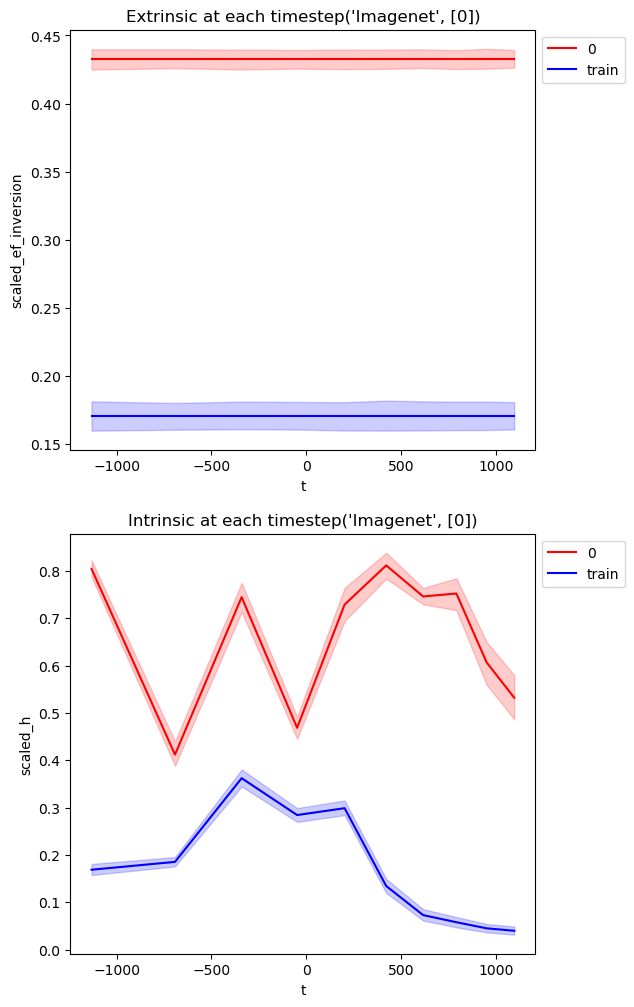

In [39]:
expriment1 = CM_Experiment_1(args, model_config, pipe)
expriment1.plot_sim()

df_anchor = expriment1.df_anchor

print("Experiment 1 Done ......")

Distance Metric L2 Computing ... start


C:\Users\user\AppData\Local\Temp\ipykernel_18204\581719645.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=concat_df, x='label_group',y='fd_h', hue_order=hue_order, palette=palette, order=hue_order)
C:\Users\user\AppData\Local\Temp\ipykernel_18204\581719645.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend to the right
C:\Users\user\AppData\Local\Temp\ipykernel_18204\581719645.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=concat_df, x='label_g

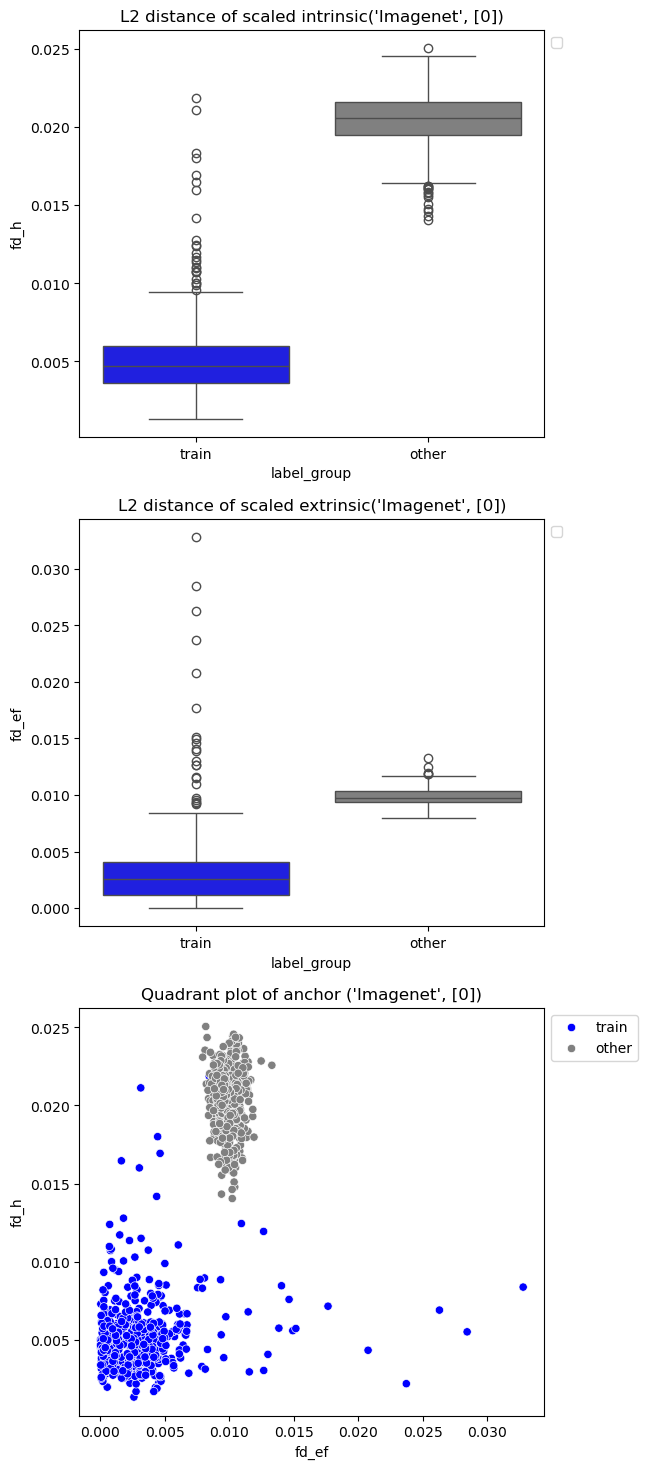

In [40]:
for dis_metric in ['L2']:
    args.metric = dis_metric
    print(f'Distance Metric {args.metric} Computing ... start')
    t_exp2 = CM_Experiment_2(args, model_config, df_anchor, metric=args.metric)
    train_mean_anchor = t_exp2.anchor_train_mean_df
    t_exp2.plot_sim()
    """
    print("experiment 2 Done ......")

    t_exp3 = t_Experiment_3(args, model_config, t_exp2.anchor_train_mean_df, t_exp2.anchor_test_mean_df)
    t_exp3.plot()
    """

In [35]:
df_anchor

,idx,is_train,label,t,ef_inversion,h,kld,scaled_ef_inversion,scaled_h,scaled_kld
0,0,False,5,1095.506659,2053.9568,29.0938,3298.8608,0.884557,0.366746,0.057758
1,1,False,0,1095.506659,2057.355,44.0938,3298.8608,0.886850,0.584328,0.057758
2,2,False,4,1095.506659,1982.4149,53.3125,3298.8608,0.836293,0.718050,0.057758
3,3,False,1,1095.506659,2099.3425,70.375,3298.8608,0.915176,0.965550,0.057758
4,4,False,9,1095.506659,2035.4243,65.5,3298.8608,0.872055,0.894835,0.057758
...,...,...,...,...,...,...,...,...,...,...
1115,6,True,train,-1131.773585,1388.6405,11.5547,4521.7471,0.435715,0.254293,0.302157
1116,7,True,train,-1131.773585,1121.6072,15.5,8013.5029,0.255566,0.438801,1.000000
1117,8,True,train,-1131.773585,1323.8528,13.8438,4324.707,0.392007,0.361347,0.262778
1118,9,True,train,-1131.773585,742.7825,12.2578,3009.8591,0.000000,0.287175,0.000000


  0%|          | 0/2 [00:00<?, ?it/s]c:\Users\user\.conda\envs\FID\lib\site-packages\diffusers\models\attention_processor.py:3286: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(
100%|██████████| 2/2 [00:00<00:00, 49.87it/s]


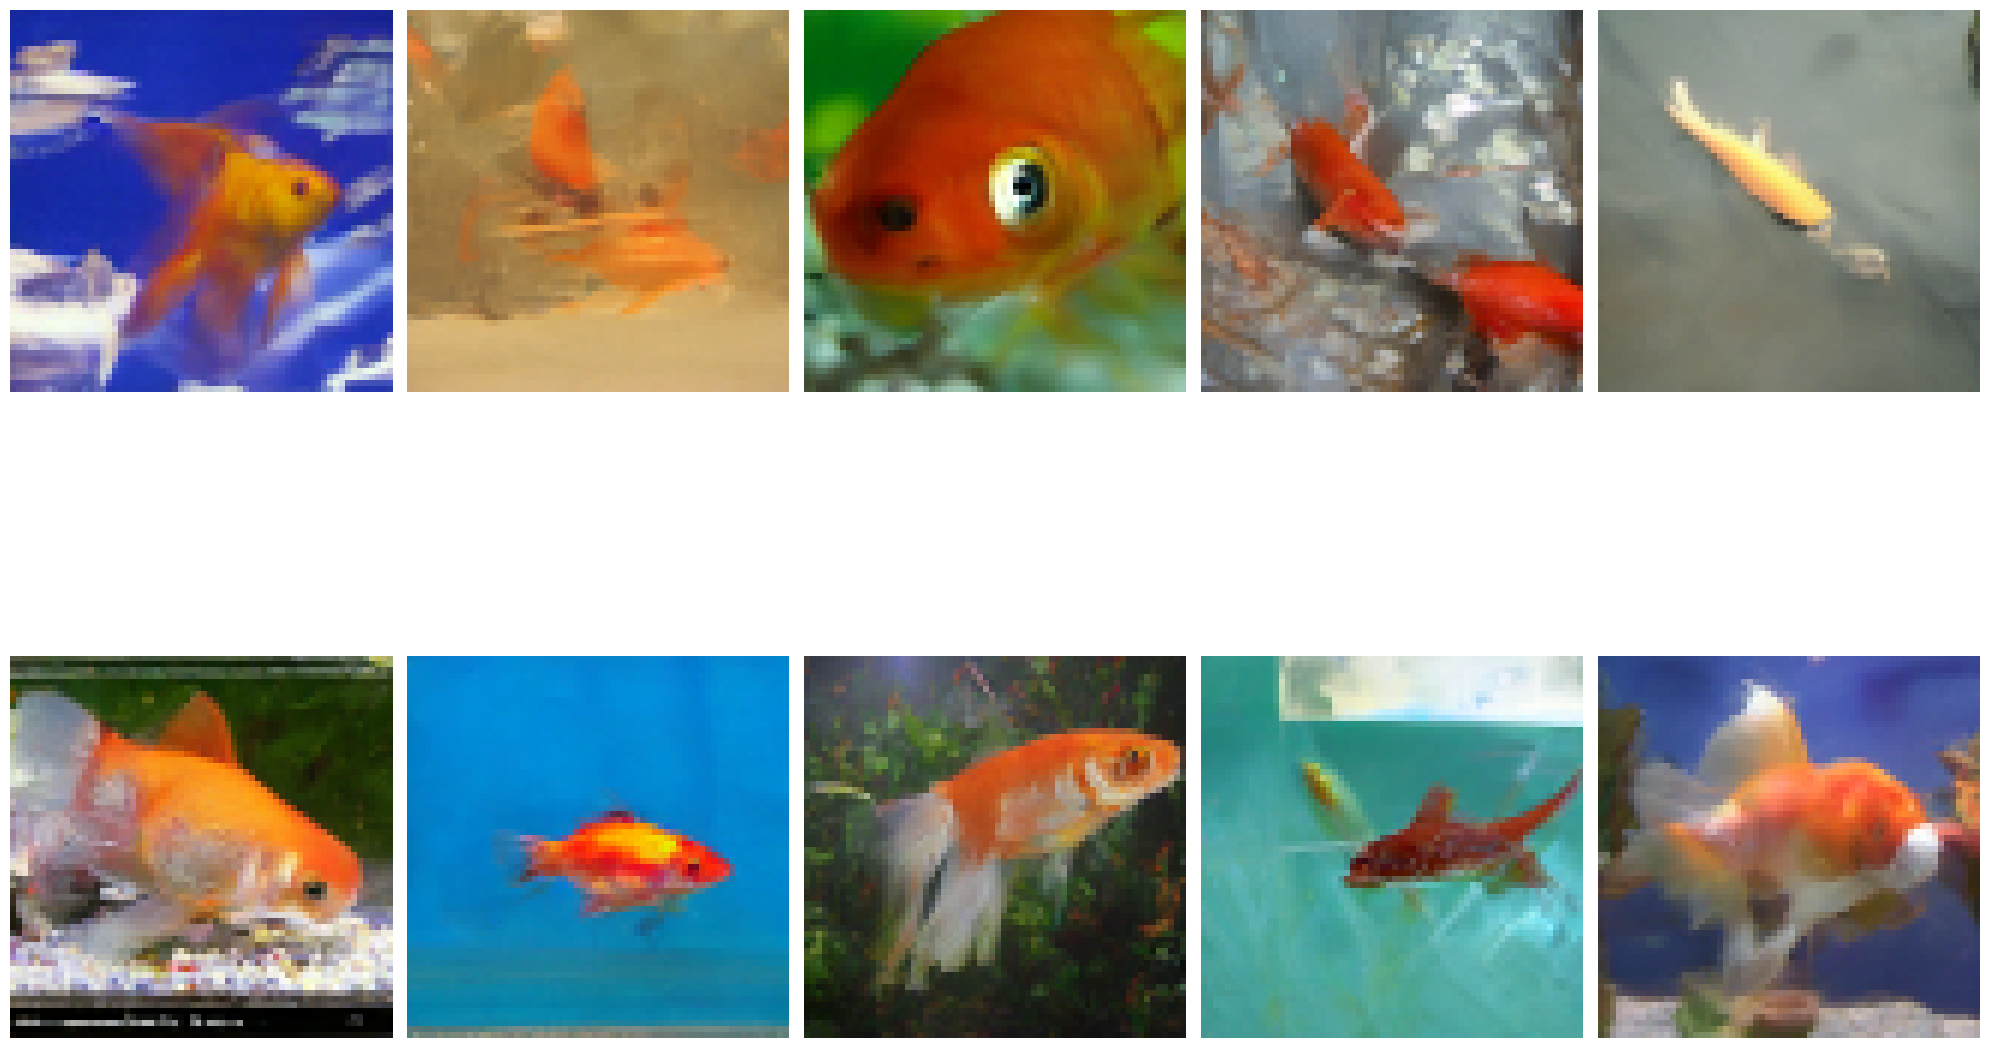

In [3]:
num_samples = 80
images = []

for _ in range(num_samples):
    image = pipe(num_inference_steps=None, timesteps=[10, 0], class_labels=1).images[0]
    images.append(image)

import matplotlib.pyplot as plt

# 設定行數與列數（可以根據需要調整）
rows, cols = 2, 5  # 8 行 x 10 列

fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.axis("off")  # 隱藏座標軸

plt.tight_layout()
plt.show()


In [4]:
from diffusers import ConsistencyModelPipeline
import torch
from PIL import Image
import torchvision.transforms as T

# Load your image (must be 64x64 for this model)
image = images[0]

# Convert to tensor in range [-1, 1]
preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])
image_tensor = preprocess(image).unsqueeze(0).to("cuda").half()


In [5]:
t = pipe.scheduler.timesteps[0].unsqueeze(0)
noise = torch.randn_like(image_tensor)
class_label = torch.tensor([1], dtype=torch.long).to(image_tensor.device)


noisy_image = pipe.scheduler.add_noise(image_tensor, noise, t)


In [7]:
noise_pred = pipe.unet(noisy_image, t, class_label).sample

In [8]:
x0_pred = pipe.scheduler.predict_start_from_noise(noisy_image, t, noise_pred)

AttributeError: 'CMStochasticIterativeScheduler' object has no attribute 'predict_start_from_noise'

In [ ]:
t_index = 0  # e.g. 你要的 timestep index
t = pipe.scheduler.timesteps[t_index].unsqueeze(0).to('cuda')
sigma_t = pipe.scheduler.sigmas[t_index]

# 已知 noisy image = x_t
noisy_image = pipe.scheduler.add_noise(image_tensor, torch.randn_like(image_tensor), t)

# 預測 noise
pred_noise = pipe.unet(
    noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
).sample

# 還原 x_0
#x0_pred = noisy_image - sigma_t * pred_noise

x0_pred = pipe.scheduler.step(pred_noise, t, noisy_image).pred_original_sample


IndexError: index 3 is out of bounds for dimension 0 with size 3

In [ ]:
x0_pred = pipe.scheduler.step(pred_noise, t, noisy_image).pred_original_sample


IndexError: index 3 is out of bounds for dimension 0 with size 3

In [ ]:
o_img = pipe.unet(noisy_image, t, class_label)

In [ ]:
x0_pred.shape

torch.Size([1, 3, 64, 64])

In [47]:
plt.imshow(x0_pred[0].permute(1, 2, 0).cpu().detach().to(torch.float32).numpy())


NameError: name 'x0_pred' is not defined

In [ ]:
pipe.unet()

TypeError: UNet2DModel.forward() missing 2 required positional arguments: 'sample' and 'timestep'

In [31]:
Imagenet_DatasetTransform = transforms.Compose([
                transforms.Resize((64,64)),
                torchvision.transforms.Grayscale(num_output_channels=3),
                transforms.ToTensor(),
                ])

dt_train = CUSTOM_DATASET(args, split=True)
train_dataset, _ = dt_train.load_dataset(custom_trasform=False)

"""
args.dataset = 'CIFAR10'
test_dataset = CIFAR10(root='./CIFAR10_ds', train=False, download=True, transform=Imagenet_DatasetTransform)
"""
args.dataset = 'MNIST'
test_dataset = MNIST(root='./MNIST_ds', train=True, download=True, transform=Imagenet_DatasetTransform)

#dt_test = CUSTOM_DATASET(args, split=False)
#_, test_dataset = dt_test.load_dataset(custom_trasform=False)


args.dataset = 'Imagenet'


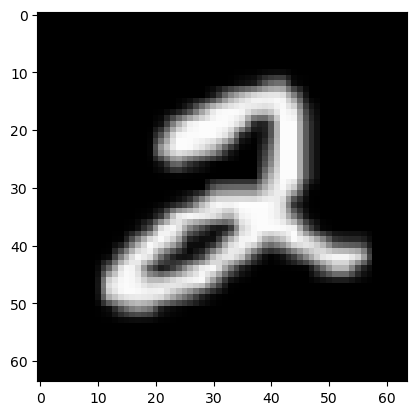

In [32]:
plt.imshow(test_dataset[5][0].permute(1,2,0))

In [6]:
features = {}

def hook(module, input, output):
    features["mid_block"] = output

hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

# 正常呼叫 UNet
output = pipe.unet(noisy_image, t, class_label)

mid_block_output = features["mid_block"]

hook_handle.remove()


In [103]:
t

tensor(-692.0998, dtype=torch.float64)

tensor([1095.5067], device='cuda:0', dtype=torch.float64)
tensor([705.0453], device='cuda:0', dtype=torch.float64)


In [12]:
t_index = 0  # e.g. 你要的 timestep index
t = pipe.scheduler.timesteps[t_index].unsqueeze(0).to('cuda')
sigma_t = pipe.scheduler.sigmas[t_index]

# 已知 noisy image = x_t
noisy_image = pipe.scheduler.add_noise(image_tensor, torch.randn_like(image_tensor), t)

# 預測 noise
pred_noise = pipe.unet(
    noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
).sample

# 還原 x_0
#x0_pred = noisy_image - sigma_t * pred_noise

x0_pred = pipe.scheduler.step(pred_noise, t, noisy_image).pred_original_sample


IndexError: index 3 is out of bounds for dimension 0 with size 3

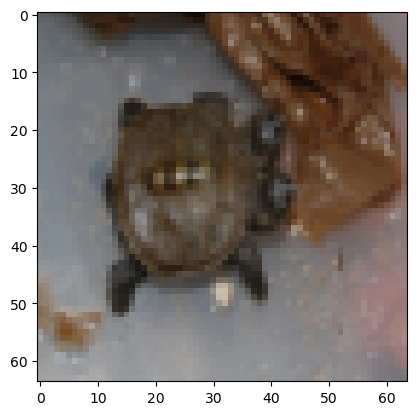

In [13]:
plt.imshow(test_dataset[2][0].permute(1,2,0).numpy())

In [6]:
def min_max_scaler(tensor, min_range=-1.0, max_range=1.0):
    """
    Applies Min-Max scaling to a tensor.
    
    Parameters:
    - tensor (torch.Tensor): The input tensor.
    - min_range (float): The minimum value of the desired range. Default is 0.0.
    - max_range (float): The maximum value of the desired range. Default is 1.0.
    
    Returns:
    - torch.Tensor: The scaled tensor.
    """
    min_val = tensor.min()
    max_val = tensor.max()
    
    # Min-Max scaling formula
    scaled_tensor = (tensor - min_val) / (max_val - min_val)
    
    # Rescale to the desired range
    scaled_tensor = scaled_tensor * (max_range - min_range) + min_range
    
    return scaled_tensor

In [44]:
from collections import defaultdict

train_extrinsic = []
other_extrinsic = []
train_intrinsic = []
other_intrinsic = []



num_samples = 80
compare_samples = 5
#batch_size = 80

num_inference_steps = 5

latents = None
callback = None
callback_steps = 1
timesteps = None
generator = None
output_type = "pil"

XLA_AVAILABLE = False

img_size = pipe.unet.config.sample_size
device = pipe._execution_device

class_label = torch.tensor([1], device=device)

model_output_dict = {}

# 0. Prepare call parameters
img_size = pipe.unet.config.sample_size
device = pipe._execution_device

# 1. Check inputs
pipe.check_inputs(num_inference_steps, timesteps, latents, num_samples, img_size, callback_steps)

# 2. Prepare image latents
# Sample image latents x_0 ~ N(0, sigma_0^2 * I)
sample = pipe.prepare_latents(
    batch_size=num_samples,
    num_channels=pipe.unet.config.in_channels,
    height=img_size,
    width=img_size,
    dtype=pipe.unet.dtype,
    device=device,
    generator=None,
    latents=latents,
)

# 3. Handle class_labels for class-conditional models
class_labels = pipe.prepare_class_labels(num_samples, device, class_labels=class_label)

# 4. Prepare timesteps
if timesteps is not None:
    pipe.scheduler.set_timesteps(timesteps=timesteps, device=device)
    timesteps = pipe.scheduler.timesteps
    num_inference_steps = len(timesteps)
else:
    pipe.scheduler.set_timesteps(num_inference_steps)
    timesteps = pipe.scheduler.timesteps




gen_images = []
# Convert to tensor in range [-1, 1]
preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])

gen_extrinsic = []
gen_intrinsic = []


features = {}

def hook(module, input, output):
    features["mid_block"] = output

preprocess = T.Compose([
    T.ToTensor(),
    #T.Normalize([0.5]*3, [0.5]*3)
])
"""

for i, t in enumerate(pipe.scheduler.timesteps):
    t = t.unsqueeze(0).to('cuda')
    noisy_image = pipe.scheduler.add_noise(image_tensor, torch.randn_like(image_tensor), t)

    pred_noise = pipe.unet(
        noisy_image, t, class_labels=torch.tensor([1]).to(image_tensor.device)
    ).sample
    
    hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

    # 正常呼叫 UNet
    output = pipe.unet(noisy_image, t, class_label)

    mid_block_output = features["mid_block"]

    hook_handle.remove()
"""


with torch.no_grad(): 
    """
    for _ in range(num_samples):
        image = pipe(num_inference_steps=None, timesteps=[10, 0], class_labels=1).images[0]
        image_tensor = preprocess(image).unsqueeze(0).to(model_config['device'])

        gen_images.append(image_tensor[0])
    """
    
    # 5. Denoising loop
    # Multistep sampling: implements Algorithm 1 in the paper
    with pipe.progress_bar(total=num_inference_steps) as progress_bar:
        for i, t in enumerate(timesteps):
            scaled_sample = pipe.scheduler.scale_model_input(sample, t)
            model_output = pipe.unet(scaled_sample, t, class_labels=class_labels, return_dict=False)[0]
            model_output_dict[i] = model_output
            
            sample = pipe.scheduler.step(model_output, t, sample, generator=generator)[0]
    
            # call the callback, if provided
            progress_bar.update()

        # 6. Post-process image sample
        image = pipe.postprocess_image(sample, output_type=output_type)
        
        for n_s in range(num_samples):
            image_tensor = preprocess(image[n_s]).unsqueeze(0).to(model_config['device'])
            gen_images.append(image_tensor[0])

    # Offload all models
    pipe.maybe_free_model_hooks()

    
    for i, t in enumerate(pipe.scheduler.timesteps):
        gen_dt_mean = 0
        gen_intrinsic_mean = 0
        for gen_dt in gen_images:
            
            
            image_scaled = gen_dt.unsqueeze(0).half()
            pred_noise = pipe.unet(
                image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            """
            
            noisy_image = pipe.scheduler.add_noise(gen_dt.unsqueeze(0), torch.randn_like(gen_dt), t.unsqueeze(0)).half()
            noisy_image_scaled = min_max_scaler(noisy_image)

            pred_noise = pipe.unet(
                noisy_image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            """

            hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

            # 正常呼叫 UNet
            output = pipe.unet(pred_noise, t, class_label)

            mid_block_output = features["mid_block"]

            hook_handle.remove
            
            gen_intrinsic_mean += mid_block_output / len(gen_images)
            gen_dt_mean += gen_dt / len(gen_images)
        
        gen_intrinsic.append(gen_intrinsic_mean)
        
        
    #calculate training data
    anchor_cnt = 0

    t_dict = defaultdict(list)
    for train_dt, _ in train_dataset:
        anchor_cnt += 1
        
        
        curr_int = 0
        for i, t in enumerate(pipe.scheduler.timesteps):
            
            image_scaled = train_dt.unsqueeze(0).half().to(model_config['device'])
            pred_noise = pipe.unet(
                image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            """

            
            noisy_image = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()
            noisy_image_scaled = min_max_scaler(noisy_image)

            pred_noise = pipe.unet(
                noisy_image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            
            """
            hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

            # 正常呼叫 UNet
            output = pipe.unet(pred_noise, t, class_label)

            mid_block_output = features["mid_block"]

            hook_handle.remove()
            t_dict[i].append(mid_block_output)
        
        if anchor_cnt < compare_samples:
            continue
        
        for i, t in enumerate(pipe.scheduler.timesteps):
            P = np.array(mid_block_output.cpu().detach())
            Q = np.array(gen_intrinsic[i].cpu().detach())
            P = P.astype(np.float32)
            Q = Q.astype(np.float32)
        int = np.sqrt(np.sum((P - Q) ** 2))
        curr_int += int
        train_intrinsic.append(curr_int)
            
        anchor_cnt = 0
        t_dict = defaultdict(list)
        
        # Extrinsic 
        curr_ext = 0
        P = np.array(train_dt)
        Q = np.array(gen_dt_mean.cpu())
        ext = np.sqrt(np.sum((P - Q) ** 2))
        curr_ext += ext / len(images)
        train_extrinsic.append(curr_ext)

    for test_n, (test_dt, _) in enumerate(test_dataset):
        curr_int = 0
        
        for i, t in enumerate(pipe.scheduler.timesteps):
            
            
            image_scaled = test_dt.unsqueeze(0).half().to(model_config['device'])
            pred_noise = pipe.unet(
                image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            
            """
            noisy_image = pipe.scheduler.add_noise(test_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(test_dt).to(model_config['device']), t.unsqueeze(0)).half()
            noisy_image_scaled = min_max_scaler(noisy_image)

            pred_noise = pipe.unet(
                noisy_image_scaled, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample
            """
            
            hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

            # 正常呼叫 UNet
            output = pipe.unet(pred_noise, t, class_label)

            mid_block_output = features["mid_block"]

            hook_handle.remove()

            P = np.array(mid_block_output.cpu().detach())
            Q = np.array(gen_intrinsic[i].cpu().detach())
            P = P.astype(np.float32)
            Q = Q.astype(np.float32)
            int = np.sqrt(np.sum((P - Q) ** 2))
            curr_int += int 
            other_intrinsic.append(curr_int)
            
            
        # Extrinsic 
        curr_ext = 0
        P = np.array(test_dt)
        Q = np.array(gen_dt_mean.cpu())
        ext = np.sqrt(np.sum((P - Q) ** 2))
        curr_ext += ext / len(images)
        other_extrinsic.append(curr_ext)
        
        
        if test_n == 1500:
            break



    """
    for train_dt, _ in train_dataset:
        curr_ext = 0
        P = np.array(train_dt)
        Q = np.array(gen_dt_mean.cpu())
        ext = np.sqrt(np.sum((P - Q) ** 2))
        curr_ext += ext / len(images)
        train_extrinsic.append(curr_ext)

    for test_n, (test_dt, _) in enumerate(test_dataset):
        curr_ext = 0
        P = np.array(test_dt)
        Q = np.array(gen_dt_mean.cpu())
        ext = np.sqrt(np.sum((P - Q) ** 2))
        curr_ext += ext / len(images)
        other_extrinsic.append(curr_ext)
            
            
        if test_n == 1500:
            break
    """


100%|██████████| 5/5 [00:01<00:00,  3.53it/s]


KeyboardInterrupt: 

In [44]:
t_dict[i].append(mid_block_output)

In [19]:
n_test = pipe.scheduler.add_noise(test_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(test_dt).to(model_config['device']), t.unsqueeze(0)).half()
n_train = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()

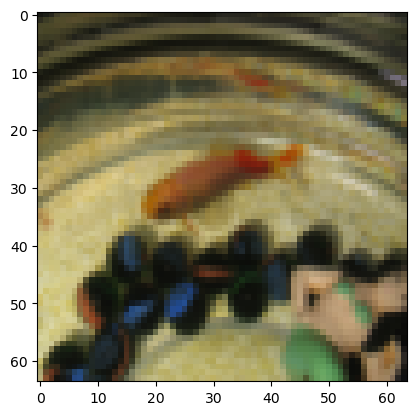

In [39]:
plt.imshow(train_dt.permute(1,2,0).cpu().numpy())

tensor([[[[ -2.4473,  -4.7188,  -9.0234,  ...,  -7.8750,  -7.5781,  -3.1133],
          [ -1.6465,   0.0609,  -5.7266,  ...,  -5.7070,  -4.9766,  -3.3164],
          [ -2.4961,  -2.9180,  -9.1016,  ..., -11.1953,  -6.8945,  -3.3926],
          ...,
          [ -2.5020,  -4.9688,  -8.9766,  ...,  -3.9453,  -1.9375,  -1.9727],
          [ -2.5566,  -5.4180,  -5.4258,  ...,  -2.8105,  -3.4355,   0.6221],
          [ -0.3391,  -2.7656,  -3.5977,  ...,  -3.3242,  -1.6172,   2.8555]],

         [[ 11.3047,   6.8828,   9.0078,  ...,   8.7344,  10.6094,  13.2969],
          [ 14.9844,   7.2695,  10.6875,  ...,  11.2344,   8.8203,   9.3203],
          [ 13.0781,   5.6211,   9.3594,  ...,  10.0625,   6.5859,  12.0391],
          ...,
          [  9.9922,   7.5039,  10.0156,  ...,   7.8906,   7.7930,   8.7578],
          [  6.9414,   4.3789,   8.1016,  ...,   8.7344,   9.3125,   9.0078],
          [  8.9609,   6.8711,   7.7383,  ...,   7.1797,   6.8672,   8.4062]],

         [[  5.9297,   9.4297,

In [47]:
mid_block_output.mean()

tensor(0.0998, device='cuda:0', dtype=torch.float16)

In [12]:
num_inference_steps = 3
batch_size = 80

latents = None
callback = None
callback_steps = 1
timesteps = None
generator = None
output_type = "pil"

XLA_AVAILABLE = False

img_size = pipe.unet.config.sample_size
device = pipe._execution_device

class_label = torch.tensor([1], device=device)

model_output_dict = {}

# 0. Prepare call parameters
img_size = pipe.unet.config.sample_size
device = pipe._execution_device

# 1. Check inputs
pipe.check_inputs(num_inference_steps, timesteps, latents, batch_size, img_size, callback_steps)

# 2. Prepare image latents
# Sample image latents x_0 ~ N(0, sigma_0^2 * I)
sample = pipe.prepare_latents(
    batch_size=batch_size,
    num_channels=pipe.unet.config.in_channels,
    height=img_size,
    width=img_size,
    dtype=pipe.unet.dtype,
    device=device,
    generator=None,
    latents=latents,
)

# 3. Handle class_labels for class-conditional models
class_labels = pipe.prepare_class_labels(batch_size, device, class_labels=class_label)

# 4. Prepare timesteps
if timesteps is not None:
    pipe.scheduler.set_timesteps(timesteps=timesteps, device=device)
    timesteps = pipe.scheduler.timesteps
    num_inference_steps = len(timesteps)
else:
    pipe.scheduler.set_timesteps(num_inference_steps)
    timesteps = pipe.scheduler.timesteps

# 5. Denoising loop
# Multistep sampling: implements Algorithm 1 in the paper
with torch.no_grad():
    with pipe.progress_bar(total=num_inference_steps) as progress_bar:
        for i, t in enumerate(timesteps):
            scaled_sample = pipe.scheduler.scale_model_input(sample, t)
            model_output = pipe.unet(scaled_sample, t, class_labels=class_labels, return_dict=False)[0]
            model_output_dict[i] = model_output
            
            sample = pipe.scheduler.step(model_output, t, sample, generator=generator)[0]
    
            # call the callback, if provided
            progress_bar.update()

# 6. Post-process image sample
image = pipe.postprocess_image(sample, output_type=output_type)

# Offload all models
pipe.maybe_free_model_hooks()

100%|██████████| 3/3 [00:00<00:00,  3.69it/s]


In [25]:
preprocess(image[0]).shape

torch.Size([3, 64, 64])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.91308594].


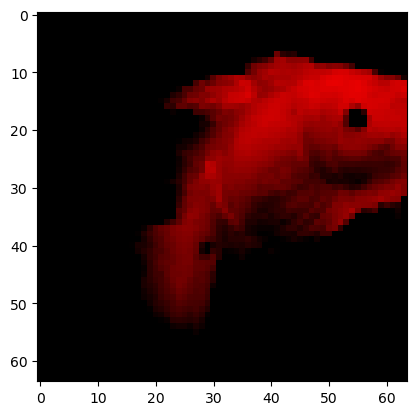

In [21]:
plt.imshow(sample[0].to(torch.float32).permute(1,2,0).cpu().numpy())

In [ ]:
train_intrinsic = []
with torch.no_grad(): 
    hook_handle = pipe.unet.mid_block.register_forward_hook(hook)
    for c, (train_dt, _)in enumerate(train_dataset):
        
        curr_int = 0
        for i, t in enumerate(pipe.scheduler.timesteps):

            noisy_image = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()

            pred_noise = pipe.unet(
                noisy_image, t, class_labels=torch.tensor([1]).to(model_config['device'])
            ).sample

            

            # 正常呼叫 UNet
            output = pipe.unet(noisy_image, t, class_label)

            mid_block_output = features["mid_block"]

            
            P = np.array(mid_block_output.cpu().detach())
            Q = np.array(gen_intrinsic[i].cpu().detach())
            P = P.astype(np.float32)
            Q = Q.astype(np.float32)
            int = np.sqrt(np.sum((P - Q) ** 2))
            curr_int += int / len(pipe.scheduler.timesteps)
            train_intrinsic.append(curr_int)
            
    
        print(c)
    hook_handle.remove()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [44]:
haha_t = torch.Tensor([1.03]).to(model_config['device']).to(torch.float64)
n = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()


In [75]:
np.sum((P - Q))

-849.5

In [59]:
noisy_image = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()

pred_noise = pipe.unet(
    noisy_image, t, class_labels=torch.tensor([1]).to(model_config['device'])
).sample
pred_noise

tensor([[[[ 1.1289,  0.7900, -0.7231,  ..., -0.2267,  0.6274,  1.3320],
          [-0.9663, -0.4980, -1.0156,  ...,  0.5898,  0.8105,  0.1003],
          [-0.0710, -0.5176, -1.3701,  ...,  0.2903,  0.3799, -1.2227],
          ...,
          [ 0.4412,  1.5254,  0.9048,  ...,  0.0667,  1.6729,  0.5039],
          [ 0.9712,  0.5610,  0.9316,  ...,  1.3389,  0.2727, -0.8745],
          [ 0.6826,  1.2803, -0.1477,  ...,  1.0566,  1.7246, -1.1055]],

         [[ 0.8711,  1.0869, -0.6162,  ..., -0.3679,  1.9111,  0.6611],
          [-0.2668, -0.0435,  0.2439,  ...,  0.6494,  1.3193,  0.6592],
          [-0.2834, -0.6406, -1.3281,  ...,  0.0586, -0.1042, -1.6719],
          ...,
          [ 0.5210,  1.1689,  1.0449,  ...,  0.5688,  1.1123,  0.8696],
          [ 1.0371,  2.0918,  1.5283,  ...,  1.0078,  1.4834, -1.4287],
          [ 1.0869,  0.7954, -0.0695,  ...,  1.6973,  0.5571, -0.6055]],

         [[ 0.9082,  0.5693, -0.4604,  ...,  0.2703,  0.9150,  0.7432],
          [-0.5386, -0.0218, -

In [47]:
haha = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()

pred_noise = pipe.unet(
    haha, t, class_labels=torch.tensor([1]).to(model_config['device'])
).sample
pred_noise

tensor([[[[ 1.2754, -0.4297,  0.1049,  ..., -1.2520, -1.3311, -0.5220],
          [ 0.7080,  0.3872, -1.2988,  ..., -0.2620, -0.9941, -0.9058],
          [ 0.1774, -0.3926, -0.0682,  ...,  0.6597, -0.8418, -1.5635],
          ...,
          [ 0.9531, -0.4170, -1.6875,  ...,  0.7842,  0.0688, -0.5845],
          [ 1.0400, -0.3965, -0.1186,  ..., -0.4685, -0.2627, -1.0869],
          [-0.3572, -0.4912, -0.8901,  ..., -1.5479, -0.9150, -0.4775]],

         [[ 1.0684,  0.4663, -1.0654,  ..., -1.8682, -0.9346, -0.6548],
          [ 1.3213, -0.2649, -0.9414,  ...,  0.4023, -1.3115,  0.2375],
          [ 0.5664, -1.1270, -0.1863,  ...,  0.6943, -0.0379, -1.3057],
          ...,
          [ 1.2246, -0.7153, -1.0312,  ...,  0.8652,  0.1110, -1.2666],
          [ 0.8193,  0.9917,  0.1500,  ..., -0.2615,  0.5806, -0.4744],
          [ 0.3804, -0.6694, -0.5610,  ..., -1.2344, -0.5820, -0.2419]],

         [[ 0.7910, -0.3523, -1.0576,  ..., -0.8706, -1.5107, -0.2087],
          [ 0.8838, -0.8184, -

In [69]:
noisy_image = pipe.scheduler.add_noise(train_dt.unsqueeze(0).to(model_config['device']), torch.randn_like(train_dt).to(model_config['device']), t.unsqueeze(0)).half()

pred_noise = pipe.unet(
    noisy_image, t, class_labels=torch.tensor([1]).to(model_config['device'])
).sample

hook_handle = pipe.unet.mid_block.register_forward_hook(hook)

# 正常呼叫 UNet
output = pipe.unet(noisy_image, t, class_label)

mid_block_output = features["mid_block"]

hook_handle.remove


<bound method RemovableHandle.remove of <torch.utils.hooks.RemovableHandle object at 0x0000022E34E7BD60>>

In [11]:
np.mean(other_intrinsic)

12248.196292062921

In [15]:
np.mean(train_intrinsic)

12030.978297437814

In [34]:
np.mean(other_extrinsic), np.var(other_extrinsic)

(0.582104210755096, 8.031398121985286e-05)

In [35]:
np.mean(train_extrinsic), np.var(train_extrinsic)

(0.3458642576978757, 0.00835375594132479)

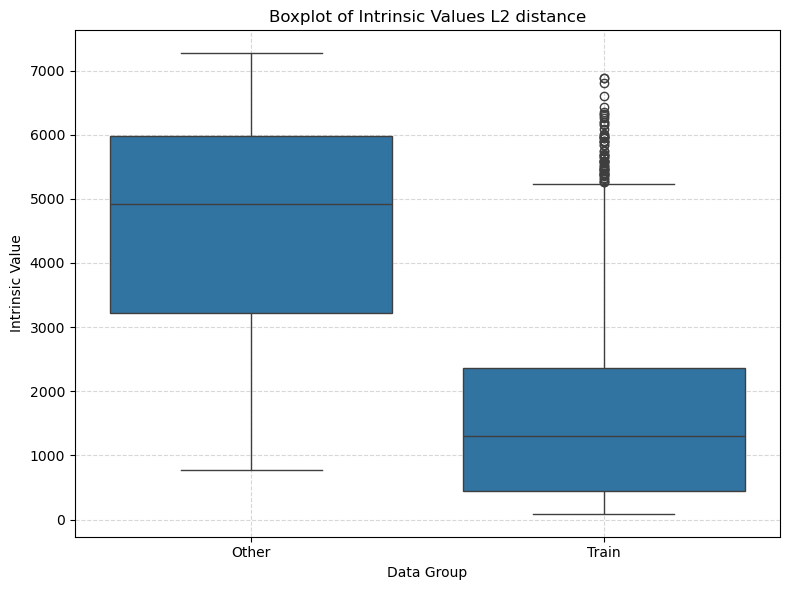

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming other_extrinsic and train_extrinsic are lists or numpy arrays
data = {
    "Value": list(other_intrinsic) + list(train_intrinsic),
    "Group": ["Other"] * len(other_intrinsic) + ["Train"] * len(train_intrinsic)
}

df = pd.DataFrame(data)

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x="Group", y="Value", data=df)
plt.title("Boxplot of Intrinsic Values L2 distance")
plt.ylabel("Intrinsic Value")
plt.xlabel("Data Group")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [35]:
len(train_dataset)

1300

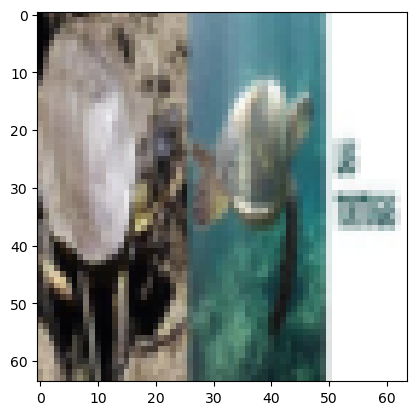

In [32]:
plt.imshow(test_dt.permute(1,2,0).numpy())

In [ ]:
test_dt.max()

tensor(1.)

In [ ]:
train_dt.max()

tensor(0.8627)

In [ ]:
gen_dt.max()

tensor(1.)